# 04 — Grafo de coparticipação: detecção de conluio (jan/2023)

Construção de grafo onde nós = empresas e arestas = coparticipação em licitações
(peso = nº de coparticipações). Detecção de comunidades via Louvain, refinada por
análise de rodízio de vitórias (Flag Vencedor).

## Metodologia
- Filtro de foco: licitações com 2–15 participantes (exclui dispensas sem disputa
  e pregões super-concorridos, onde conluio é improvável e o grafo explodiria —
  uma licitação tinha 8.038 participantes).
- Grafo: 2.473 empresas, 9.071 arestas.

## Achados e classificação
Três perfis distintos de coparticipação concentrada, distinguidos por conhecimento
de domínio (o algoritmo sozinho não separa oligopólio de cartel):
- **Oligopólio legítimo** — farmacêuticas/oncológicos (Roche, Novartis, CM Hospitalar):
  concentração estrutural do mercado (poucos players habilitados). Arquivar.
- **Mercado concorrido** — terceirização/limpeza (38 empresas): coparticipam muito
  mas NÃO capturam vitórias (vazam para fora do grupo). Monitorar.
- **Suspeita prioritária** — 9 construtoras em licitações da CODEVASF (Vale do São
  Francisco): grupo fechado, sem razão estrutural para concentração, núcleo de 4
  captura vitórias em rodízio, com repartição por lotes numa mesma licitação.
  **Recomendado para auditoria manual** dos 8 processos identificados.

## Lição metodológica
O padrão estatístico do cartel (grupo fechado + vitórias distribuídas) é idêntico
ao de um oligopólio legítimo. A distinção exige contexto setorial — não sai do dado.

In [1]:
import sys
sys.path.append("..")

import pandas as pd

# Comecamos com UM mes para entender a estrutura (o arquivo e pesado)
part = pd.read_csv(
    "../data/raw/202301_ParticipantesLicitação.csv",
    sep=";", encoding="latin-1", decimal=","
)

print(part.shape)
part.columns.tolist()

(265751, 13)


['Número Licitação',
 'Código UG',
 'Nome UG',
 'Código Modalidade Compra',
 'Modalidade Compra',
 'Número Processo',
 'Código Órgão',
 'Nome Órgão',
 'Código Item Compra',
 'Descrição Item Compra',
 'Código Participante',
 'Nome Participante',
 'Flag Vencedor']

In [2]:
# Como o vencedor esta marcado?
print(part["Flag Vencedor"].value_counts())

# Quantos participantes distintos, quantas licitacoes distintas?
print("\nParticipantes únicos:", part["Código Participante"].nunique())
print("Licitações únicas (UG + Número):",
      part.groupby(["Código UG", "Número Licitação"]).ngroups)

# Quantos participantes por licitacao, em media? (licitacao com 1 so participante
# nao serve pro grafo — precisa de pelo menos 2 pra ter aresta)
part_por_lic = part.groupby(["Código UG", "Número Licitação"]).size()
print("\nDistribuição de participantes por licitação:")
print(part_por_lic.describe())

Flag Vencedor
NÃO    217194
SIM     48557
Name: count, dtype: int64

Participantes únicos: 10938
Licitações únicas (UG + Número): 3400

Distribuição de participantes por licitação:
count    3400.000000
mean       78.162059
std       313.773404
min         1.000000
25%         1.000000
50%         3.000000
75%        31.250000
max      8038.000000
dtype: float64


In [3]:
# Quantas licitacoes tem participante "de menos" (1) e "de mais" (>15)?
print("Licitações com 1 participante (sem disputa):", (part_por_lic == 1).sum())
print("Licitações com 2-15 participantes (foco):",
      ((part_por_lic >= 2) & (part_por_lic <= 15)).sum())
print("Licitações com >15 participantes (super-concorridas):",
      (part_por_lic > 15).sum())

# Quanto do total de LINHAS cada faixa representa?
faixa_foco = part_por_lic[(part_por_lic >= 2) & (part_por_lic <= 15)]
print(f"\nLicitações no foco: {len(faixa_foco)}")
print(f"Participações somadas no foco: {faixa_foco.sum()}")

Licitações com 1 participante (sem disputa): 1280
Licitações com 2-15 participantes (foco): 1038
Licitações com >15 participantes (super-concorridas): 1082

Licitações no foco: 1038
Participações somadas no foco: 5930


In [4]:
%pip install networkx

Note: you may need to restart the kernel to use updated packages.


In [5]:
from src.grafo import filtrar_licitacoes_disputadas, construir_grafo_coparticipacao

part_foco = filtrar_licitacoes_disputadas(part)
print("Participações no foco:", len(part_foco))

G = construir_grafo_coparticipacao(part_foco)
print("Empresas (nós):", G.number_of_nodes())
print("Conexões (arestas):", G.number_of_edges())

Participações no foco: 5930
Empresas (nós): 2473
Conexões (arestas): 9071


In [6]:
from src.grafo import top_pares_coparticipacao

pares = top_pares_coparticipacao(G, n=20)
pares

,empresa_a,empresa_b,coparticipacoes
0,00482840000138,11077741000197,10
1,76484013000145,04368898000106,9
2,17303236000108,11077741000197,5
3,11077741000197,20334262000108,4
4,23080111000150,11077741000197,4
5,00482840000138,17303236000108,4
6,12420164000904,33009945000204,4
7,07017934000185,08804362000147,4
8,09053134000145,56994502002698,4
9,19758842000135,19758779000137,4


In [7]:
# Dicionario codigo -> nome da empresa
nomes = part_foco.drop_duplicates("Código Participante").set_index("Código Participante")["Nome Participante"]

pares["nome_a"] = pares["empresa_a"].map(nomes)
pares["nome_b"] = pares["empresa_b"].map(nomes)
pares[["nome_a", "nome_b", "coparticipacoes"]]

,nome_a,nome_b,coparticipacoes
0,LIDERANCA LIMPEZA E CONSERVACAO LTDA,VALEX SERVICOS TECNICOS DE LIMPEZA LTDA,10
1,COMPANHIA DE SANEAMENTO DO PARANA SANEPAR,COPEL DISTRIBUICAO S.A.,9
2,MANACAPURU LIMPEZA E CONSERVACAO LTDA,VALEX SERVICOS TECNICOS DE LIMPEZA LTDA,5
3,VALEX SERVICOS TECNICOS DE LIMPEZA LTDA,CSB3 PRESTACAO DE SERVICOS LTDA,4
4,A3 LOCACAO DE MAO DE OBRA E SERVICOS LTDA,VALEX SERVICOS TECNICOS DE LIMPEZA LTDA,4
5,LIDERANCA LIMPEZA E CONSERVACAO LTDA,MANACAPURU LIMPEZA E CONSERVACAO LTDA,4
6,CM HOSPITALAR S.A.,PRODUTOS ROCHE QUIMICOS E FARMACEUTICOS S A,4
7,VALE DO RIBEIRA INTERNET LTDA,FACHINELI COMUNICACAO LTDA,4
8,ELFA MEDICAMENTOS S.A,NOVARTIS BIOCIENCIAS SA,4
9,LCM CONSTRUCAO E COMERCIO S.A,ETHOS ENGENHARIA DE INFRAESTRUTURA S/A,4


In [8]:
from src.grafo import detectar_comunidades

comunidades = detectar_comunidades(G, peso_minimo=2)
print(f"Comunidades encontradas: {len(comunidades)}")
print(f"Tamanhos das 10 maiores: {[len(c) for c in comunidades[:10]]}")

# Olha a maior comunidade com nomes
maior = comunidades[0]
print(f"\nMaior comunidade ({len(maior)} empresas):")
for codigo in list(maior)[:15]:
    print(" -", nomes.get(codigo, codigo))

Comunidades encontradas: 45
Tamanhos das 10 maiores: [38, 16, 11, 9, 7, 7, 6, 6, 6, 6]

Maior comunidade (38 empresas):
 - FOCUS GESTAO ADMINISTRATIVA LTDA
 - COENE GESTAO EM SERVICOS DE LIMPEZA LTDA
 - NORTE MANA COMERCIO DE ALIMENTOS E SERVICOS DE LIMPEZA LTDA
 - SUSTENTAVEL ENGENHARIA E SERVICOS LTDA
 - IMPERIO SERVICOS LTDA
 - VIVA SERVICOS LTDA
 - DAMASCENO SERVICOS LTDA
 - ACS CONSULTORIA E SERVICOS LTDA
 - LM SERVICOS TERCEIRIZADOS LTDA
 - X BELMAX SERVICE LTDA
 - MEGA 3 CONSTRUCAO LTDA
 - M.S.V. SISTEMAS DE SEGURANA LTDA - MASSA FALIDA
 - DELTA SERVICOS DE PORTARIA E LIMPEZA LTDA
 - NOVA RIO SERVICOS GERAIS LTDA
 - MASTHER SERVICOS E CONSTRUCOES LTDA


In [9]:
from src.grafo import analisar_comunidade

# Analisa a maior comunidade
resultado = analisar_comunidade(part_foco, G, comunidades[0])
print("Empresas na comunidade:", resultado["n_empresas"])
print("Licitações com disputa interna:", resultado["n_licitacoes_disputa_interna"])
print("\nRodízio de vitórias (top 15):")
for cod, v in resultado["vitorias_por_empresa"].head(15).items():
    print(f"  {v:3d} vitórias - {nomes.get(cod, cod)}")

Empresas na comunidade: 38
Licitações com disputa interna: 24

Rodízio de vitórias (top 15):
    2 vitórias - LIDERANCA LIMPEZA E CONSERVACAO LTDA
    2 vitórias - SERVIIR SERVICOS DE TRADUCAO INTERPRETACAO E TECNOLOGIA LTDA
    1 vitórias - IMPACTO SERVICOS TERCEIRIZADOS LTDA
    1 vitórias - A3 LOCACAO DE MAO DE OBRA E SERVICOS LTDA
    1 vitórias - MEGA 3 CONSTRUCAO LTDA
    1 vitórias - KANTRO EMPREENDIMENTOS APOIO E SERVICOS LTDA


In [10]:
# Analisa TODAS as comunidades de tamanho "suspeito" (4 a 12 empresas)
# e mede concentracao de vitorias internas
print("Análise das comunidades de tamanho 4-12 (candidatas a cartel fechado):\n")

for i, com in enumerate(comunidades):
    if not (4 <= len(com) <= 12):
        continue
    res = analisar_comunidade(part_foco, G, com)
    vit = res["vitorias_por_empresa"]
    n_disputas = res["n_licitacoes_disputa_interna"]
    total_vit = vit.sum()

    if n_disputas < 3:
        continue  # poucas disputas, sem sinal

    # Concentracao: quantas empresas dividem as vitorias?
    empresas_vencedoras = (vit > 0).sum()
    print(f"Comunidade {i}: {len(com)} empresas, {n_disputas} disputas internas, "
          f"{total_vit} vitórias entre {empresas_vencedoras} empresas")
    for cod, v in vit.head(6).items():
        print(f"    {v:3d}x - {nomes.get(cod, cod)}")
    print()
    

Análise das comunidades de tamanho 4-12 (candidatas a cartel fechado):

Comunidade 2: 11 empresas, 12 disputas internas, 7 vitórias entre 4 empresas
      2x - RESSURGENCIA AERO MARINE DO BRASIL LTDA
      2x - LE' ANNAS COMERCIO DE PECAS E EQUIPAMENTOS ELETRONICOS LTDA
      2x - WIKA DO BRASIL INDUSTRIA E COMERCIO LTDA
      1x - MICROBAC PRODUTOS E SERVICOS PARA LABORATORIOS LTDA

Comunidade 3: 9 empresas, 8 disputas internas, 8 vitórias entre 4 empresas
      3x - MOBICON CONSTRUTORA LTDA
      2x - LIGA ENGENHARIA LTDA
      2x - DFRANCO CONSTRUCOES E SERVICOS LTDA
      1x - GAISSLER MOREIRA ENGENHARIA CIVIL LTDA

Comunidade 4: 7 empresas, 4 disputas internas, 3 vitórias entre 2 empresas
      2x - SPORTS EMPORIO, PAPELARIA E INFORMATICA LTDA
      1x - INSTASOLUTIONS PRODUTOS E GESTAO EMPRESARIAL LTDA

Comunidade 5: 7 empresas, 16 disputas internas, 61 vitórias entre 7 empresas
     17x - CM HOSPITALAR S.A.
     11x - ELFA MEDICAMENTOS S.A
      9x - PRODUTOS ROCHE QUIMICOS E FA

In [11]:
# Investigacao detalhada da Comunidade 3 (construcao - suspeita prioritaria)
com3 = comunidades[3]

# Quem sao os 9, e o de-para de vitorias
print("=== Comunidade 3 — Construção/Engenharia ===\n")
for cod in com3:
    print(" -", nomes.get(cod, cod))

# As licitacoes especificas onde eles disputaram entre si
membros3 = set(com3)
p3 = part_foco[part_foco["Código Participante"].isin(membros3)]
lics3 = p3.groupby(["Código UG", "Número Licitação", "Nome UG"]).agg(
    n_membros=("Código Participante", "nunique"),
    vencedor=("Flag Vencedor", lambda x: (x == "SIM").sum()),
).reset_index()
lics3 = lics3[lics3["n_membros"] >= 2].sort_values("n_membros", ascending=False)
print(f"\n{len(lics3)} licitações com disputa interna:")
lics3

=== Comunidade 3 — Construção/Engenharia ===

 - LIGA ENGENHARIA LTDA
 - CONSTRUTORA INVEZT LTDA
 - MOBICON CONSTRUTORA LTDA
 - DFRANCO CONSTRUCOES E SERVICOS LTDA
 - GAISSLER MOREIRA ENGENHARIA CIVIL LTDA
 - CONSTRUITA CONSTRUCOES E INCORPORACAO LTDA
 - CONSTRUTORA ANCAR LTDA
 - TV - TECNICA VIARIA CONSTRUCOES LTDA
 - B7 EMPREENDIMENTOS LTDA

8 licitações com disputa interna:


,Código UG,Número Licitação,Nome UG,n_membros,vencedor
4,195002,252022,CIA DE DES.DOS VALES DO S.FRANC.E DO PARNAIBA,4,1
2,195002,232022,CIA DE DES.DOS VALES DO S.FRANC.E DO PARNAIBA,3,0
3,195002,242022,CIA DE DES.DOS VALES DO S.FRANC.E DO PARNAIBA,3,1
5,195006,612022,CIA DE DES.DOS VALES DO S.FRANC.E DO PARNAIBA,3,1
6,195006,692022,CIA DE DES.DOS VALES DO S.FRANC.E DO PARNAIBA,3,1
7,195006,862022,CIA DE DES.DOS VALES DO S.FRANC.E DO PARNAIBA,3,3
9,393028,5232022,SUPERINTENDENCIA REG. NO ESTADO PR - DNIT,3,0
10,393028,5242022,SUPERINTENDENCIA REG. NO ESTADO PR - DNIT,3,1


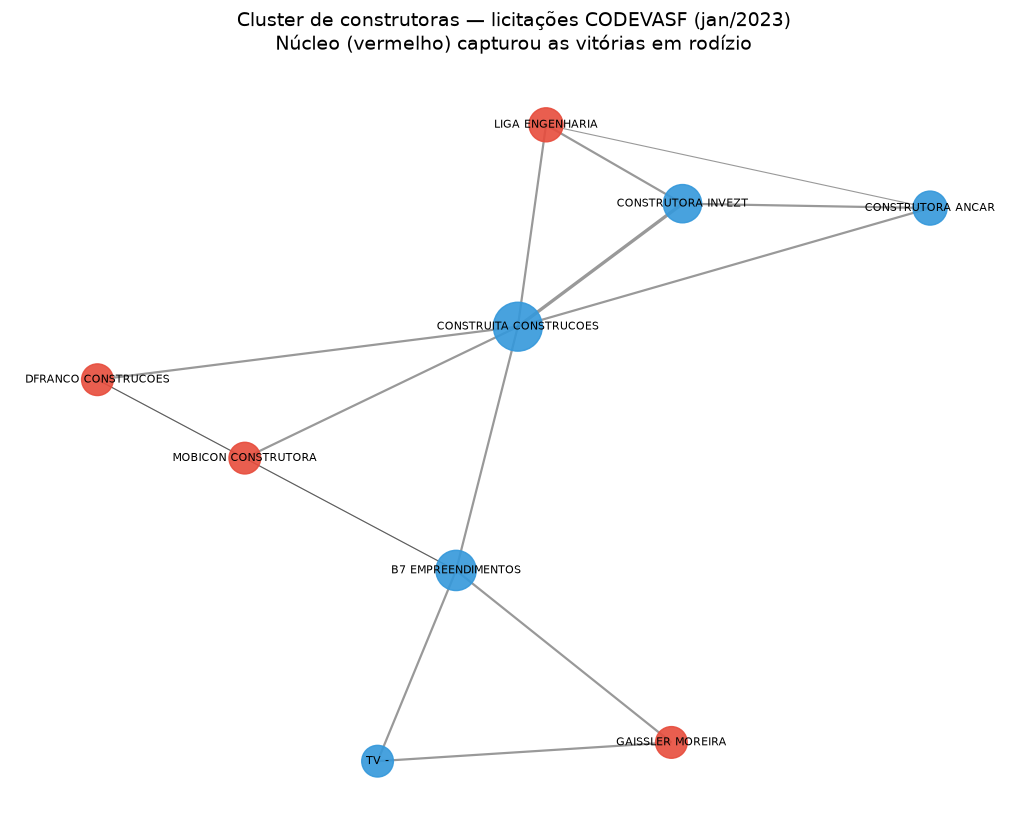

In [ ]:
from src.grafo import desenhar_comunidade

# Os 4 vencedores do nucleo (da analise anterior)
nucleo = ["MOBICON", "LIGA ENGENHARIA", "DFRANCO", "GAISSLER"]  # ajustar p/ codigos
# Melhor: pegar os codigos dos que venceram
codigos_nucleo = [cod for cod in com3
                if any(nome in str(nomes.get(cod, "")).upper()
                        for nome in ["MOBICON", "LIGA ENG", "DFRANCO", "GAISSLER"])]

desenhar_comunidade(
    G, com3, nomes,
    titulo="Cluster de 9 construtoras — licitações CODEVASF (jan/2023)\nCoparticipação intensa; núcleo em vermelho captura vitórias — recomendado p/ auditoria",
    nucleo=codigos_nucleo,
    salvar="../reports/grafo_codevasf.png"
)